In [11]:
import pathlib
import scanpy as sc
import anndata as ad
from tqdm import tqdm

In [12]:
adatas = {
    filename.name[:-5]: sc.read_h5ad(filename)
    for filename in tqdm(pathlib.Path("/oak/stanford/projects/kibr/Reorganizing/Projects/James/lipid-droplet-pipeline/data/processed/adata/mapped_pathology_data").glob("*-*.h5ad"))
}


12it [03:36, 18.06s/it]


In [13]:
adata = ad.concat(adatas, label="folder")

adata.write_h5ad("/oak/stanford/projects/kibr/Reorganizing/Projects/James/lipid-droplet-pipeline/data/processed/adata/mapped_pathology_data/concatenated_full_16APR2025.h5ad")

/oak/stanford/projects/kibr/Reorganizing/Projects/James/lipid-droplet-pipeline/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


<Axes: ylabel='Density'>

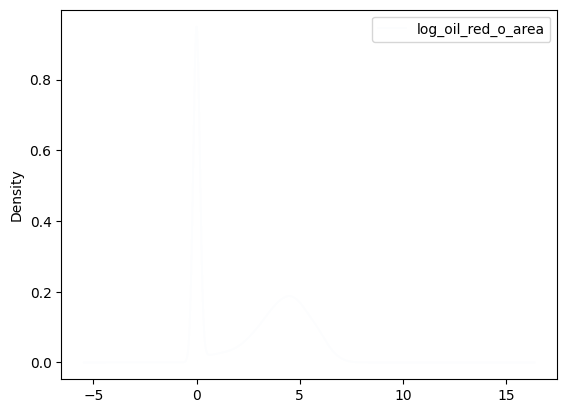

In [10]:
adata.obs.eval("log_plin2_area = log(1+plin2_area)") \
    .eval("log_oil_red_o_area = log(1+oil_red_o_area)") \
    .eval("log_lipid_droplet_area = log(1+lipid_droplet_area)") \
    .plot.kde(x="log_plin2_area", y="log_oil_red_o_area", alpha=0.01)